**LIBRARY IMPORT**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
import warnings
import urllib.request
import io

from Bio import Entrez, SeqIO
from Bio.SeqUtils import gc_fraction

In [ ]:
URL_ALBACARES = "https://raw.githubusercontent.com/PoisonAifih/Compbio_TunaFasta/main/NCBI_Thunnus_albacares.fasta"
URL_THYNNUS   = "https://raw.githubusercontent.com/PoisonAifih/Compbio_TunaFasta/main/NCBI_Thunnus_thynnus.fasta"

#1: **DATA COLLECTION**

In [ ]:
def fetch_sequence(url, species_name):
    print(f"Fetching {species_name} sequence from GitHub...")
    try:
        with urllib.request.urlopen(url) as response:
            fasta_text = response.read().decode("utf-8")
        fasta_io = io.StringIO(fasta_text)
        record = SeqIO.read(fasta_io, "fasta")
        seq = str(record.seq).upper()
        print(f"Got Sequence length: {len(seq)} bases")
        print(f"ID: {record.id}")
        return seq
    except Exception as e:
        raise RuntimeError(f"Failed to fetch {species_name} from {url}.\nError: {e}")

MAX_LENGTH = 200
seq1_full = fetch_sequence(URL_ALBACARES, "T. albacares")
seq2_full = fetch_sequence(URL_THYNNUS,   "T. thynnus")

seq1_raw = seq1_full[:MAX_LENGTH]
seq2_raw = seq2_full[:MAX_LENGTH]

print("\n--- Raw Sequence ---")
print(f"T. albacares : {len(seq1_raw)} bases")
print(f"T. thynnus   : {len(seq2_raw)} bases")

Fetching T. albacares sequence from GitHub...
Got Sequence length: 656 bases
ID: PX970111.1
Fetching T. thynnus sequence from GitHub...
Got Sequence length: 652 bases
ID: PX454683.1

--- Raw Sequence ---
T. albacares : 200 bases
T. thynnus   : 200 bases


#2: **DATA CLEANING**

Check for invalid/ambiguous characters in a DNA sequence.
    Valid characters are A, T, G, C only.

In [ ]:
def check_missing_values(seq, species_name):
    valid = set("ATGC")
    invalid_chars = [b for b in seq if b not in valid]
    print(f"\n[{species_name}] Length: {len(seq)} | Invalid characters found: {len(invalid_chars)}")
    if invalid_chars:
        print(f"  Ambiguous characters: {set(invalid_chars)}")
    else:
        print("  No missing values detected.")
    return invalid_chars


Remove any character that is not A, T, G, or C.


In [ ]:
def clean_sequence(seq):
    valid = set("ATGC")
    return "".join([b for b in seq if b in valid])

print("\n--- Before Cleaning ---")
mv1 = check_missing_values(seq1_raw, "T. albacares")
mv2 = check_missing_values(seq2_raw, "T. thynnus")

seq1 = clean_sequence(seq1_raw)
seq2 = clean_sequence(seq2_raw)

print("\n--- After Cleaning ---")
print(f"T. albacares : {len(seq1_raw)} -> {len(seq1)}")
print(f"T. thynnus   : {len(seq2_raw)} -> {len(seq2)}")



--- Before Cleaning ---

[T. albacares] Length: 200 | Invalid characters found: 0
  No missing values detected.

[T. thynnus] Length: 200 | Invalid characters found: 0
  No missing values detected.

--- After Cleaning ---
T. albacares : 200 -> 200
T. thynnus   : 200 -> 200


# 3. **EXPLORATORY DATA ANALYSIS (EDA)**

Computes and prints nucleotide frequency and GC/AT contentfor a given DNA sequence.

In [ ]:
def compute_statistics(seq, species_name):

    counter = Counter(seq)
    gc = gc_fraction(seq)
    at = 100 - gc
    print(f"\nStatistics [{species_name}]")
    print(f"Length     : {len(seq)} bases")
    print(f"A: {counter['A']}  T: {counter['T']}  G: {counter['G']}  C: {counter['C']}")
    print(f"GC Content : {gc:.2f}%")
    print(f"AT Content : {at:.2f}%")
    return counter, gc


counter1, gc1 = compute_statistics(seq1, "T. albacares")
counter2, gc2 = compute_statistics(seq2, "T. thynnus")



Statistics [T. albacares]
Length     : 200 bases
A: 51  T: 61  G: 44  C: 44
GC Content : 0.44%
AT Content : 99.56%

Statistics [T. thynnus]
Length     : 200 bases
A: 51  T: 58  G: 47  C: 44
GC Content : 0.46%
AT Content : 99.55%


**EDA VISUALIZATION**

Nucleotide frequency bar plots + GC/AT comparison:
    

    * Top row: nucleotide frequency bar charts for each species
    * Bottom left: GC vs AT pie chart for T. albacares
    * Bottom right: grouped GC/AT bar chart comparing both species


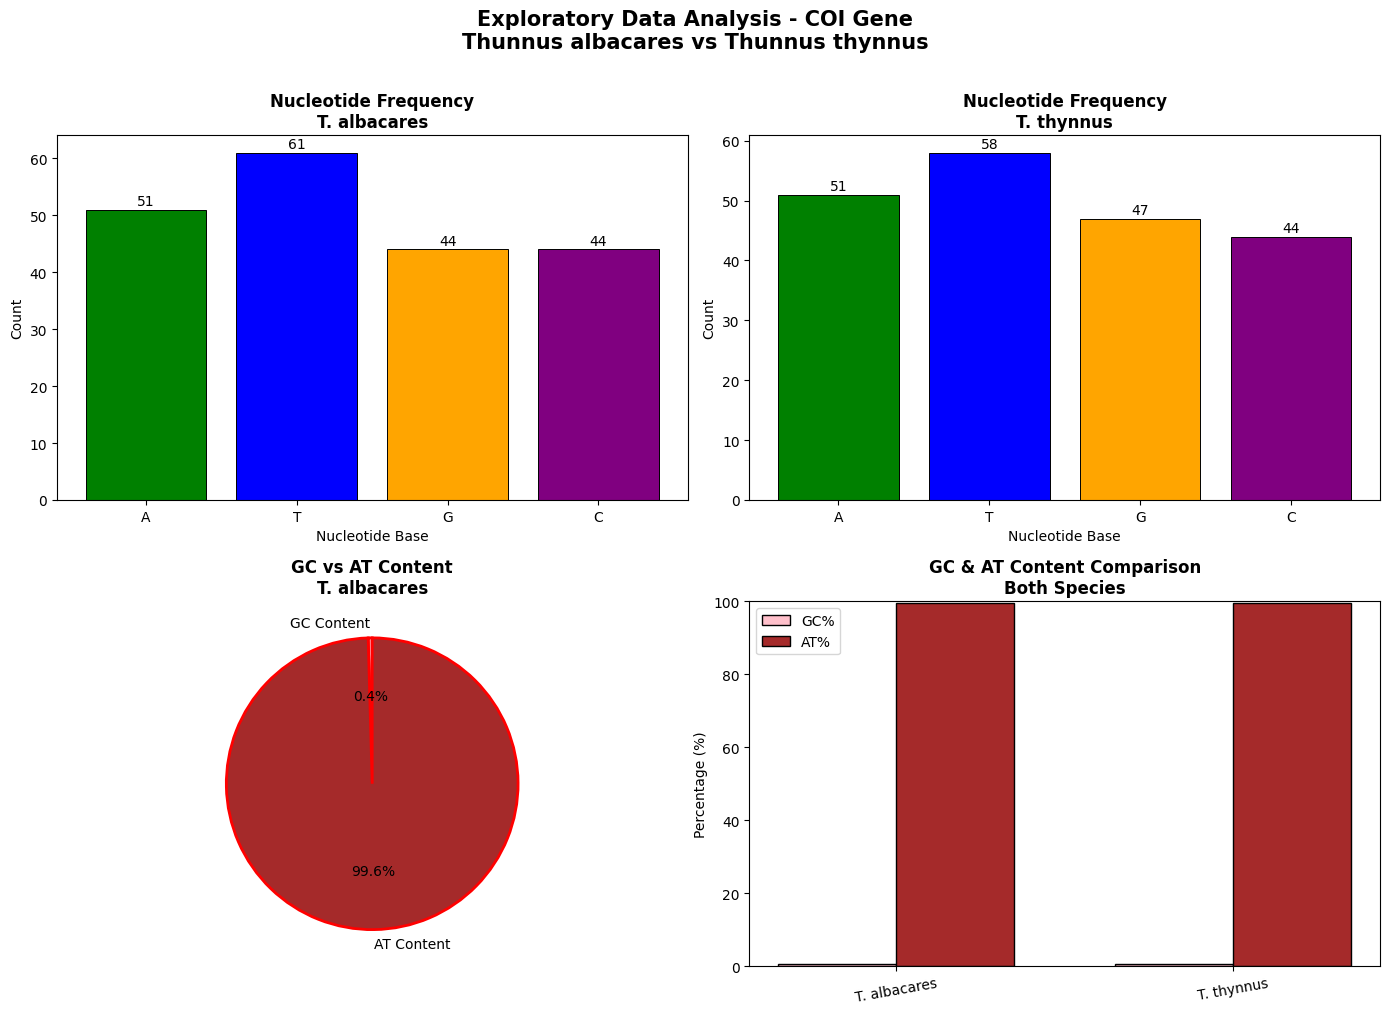

In [ ]:
def plot_nucleotide_frequencies(counter1, counter2, gc1, gc2):

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(
        "Exploratory Data Analysis - COI Gene\nThunnus albacares vs Thunnus thynnus",
        fontsize=15, fontweight='bold', y=1.01
    )

    bases = ['A', 'T', 'G', 'C']
    colors = ['green', 'blue', 'orange', 'purple']

    ax1 = axes[0, 0]
    vals1 = [counter1[b] for b in bases]
    bars1 = ax1.bar(bases, vals1, color=colors, edgecolor='black', linewidth=0.7)
    ax1.set_title("Nucleotide Frequency\nT. albacares", fontweight='bold')
    ax1.set_xlabel("Nucleotide Base")
    ax1.set_ylabel("Count")
    for bar, val in zip(bars1, vals1):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(val), ha='center', va='bottom', fontsize=10)

    ax2 = axes[0, 1]
    vals2 = [counter2[b] for b in bases]
    bars2 = ax2.bar(bases, vals2, color=colors, edgecolor='black', linewidth=0.7)
    ax2.set_title("Nucleotide Frequency\nT. thynnus", fontweight='bold')
    ax2.set_xlabel("Nucleotide Base")
    ax2.set_ylabel("Count")
    for bar, val in zip(bars2, vals2):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(val), ha='center', va='bottom', fontsize=10)

    ax3 = axes[1, 0]
    ax3.pie([gc1, 100 - gc1], labels=['GC Content', 'AT Content'],
            autopct='%1.1f%%', colors=['pink', 'brown'],
            startangle=90, wedgeprops={'edgecolor': 'red', 'linewidth': 2})
    ax3.set_title("GC vs AT Content\nT. albacares", fontweight='bold')

    ax4 = axes[1, 1]
    species_labels = ['T. albacares', 'T. thynnus']
    gc_vals = [gc1, gc2]
    at_vals = [100 - gc1, 100 - gc2]
    x = np.arange(len(species_labels))
    w = 0.35
    ax4.bar(x - w/2, gc_vals, w, label='GC%', color='pink', edgecolor='black')
    ax4.bar(x + w/2, at_vals, w, label='AT%', color='brown', edgecolor='black')
    ax4.set_title("GC & AT Content Comparison\nBoth Species", fontweight='bold')
    ax4.set_xticks(x)
    ax4.set_xticklabels(species_labels, rotation=10)
    ax4.set_ylabel("Percentage (%)")
    ax4.legend()
    ax4.set_ylim(0, 100)

    plt.tight_layout()
    plt.show()

plot_nucleotide_frequencies(counter1, counter2, gc1, gc2)




GC content sliding window ->
     `Plots GC content across a sliding window of `window` base pairs for both species, showing regional variation along the COI gene.`
     
   

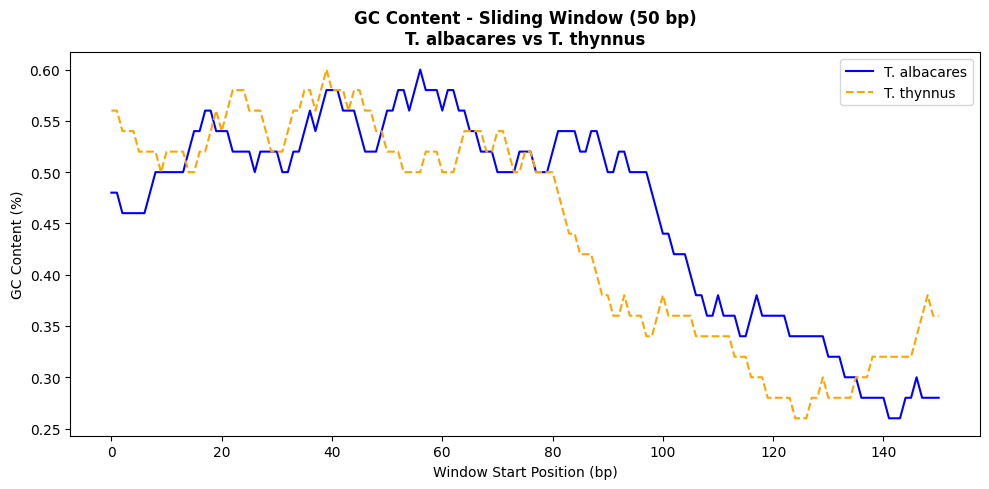

In [ ]:
def plot_gc_sliding_window(seq1, seq2, window=50):

    def gc_windows(seq, w):
        return [gc_fraction(seq[i:i+w]) for i in range(len(seq) - w + 1)]

    win1 = gc_windows(seq1, window)
    win2 = gc_windows(seq2, window)

    plt.figure(figsize=(10, 5))
    plt.plot(win1, color='blue', label='T. albacares', linewidth=1.5)
    plt.plot(win2, color='orange', label='T. thynnus',   linewidth=1.5, linestyle='--')
    plt.title(f"GC Content - Sliding Window ({window} bp)\nT. albacares vs T. thynnus",
              fontweight='bold')
    plt.xlabel("Window Start Position (bp)")
    plt.ylabel("GC Content (%)")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_gc_sliding_window(seq1, seq2)



# 4. **NEEDLEMAN-WUNSCH IMPLEMENTATION**

In [ ]:
MATCH =  1
MISMATCH = -1
GAP = -2


def build_score_matrix(seq1, seq2, match, mismatch, gap):
    n = len(seq1)
    m = len(seq2)
    matrix = np.zeros((m + 1, n + 1), dtype=int)

    for i in range(m + 1):
        matrix[i][0] = i * gap
    for j in range(n + 1):
        matrix[0][j] = j * gap

    for i in range(1, m + 1):
        for j in range(1, n + 1):
            diag = matrix[i-1][j-1] + (match if seq2[i-1] == seq1[j-1] else mismatch)
            up   = matrix[i-1][j] + gap
            left = matrix[i][j-1] + gap
            matrix[i][j] = max(diag, up, left)

    return matrix


def traceback_alignment(seq1, seq2, matrix, match, mismatch, gap):
    aligned1, aligned2 = "", ""
    i, j = len(seq2), len(seq1)

    while i > 0 or j > 0:
        current = matrix[i][j]
        if i > 0 and j > 0:
            expected_diag = matrix[i-1][j-1] + (match if seq2[i-1] == seq1[j-1] else mismatch)
            if current == expected_diag:
                aligned1 = seq1[j-1] + aligned1
                aligned2 = seq2[i-1] + aligned2
                i -= 1; j -= 1
            elif current == matrix[i-1][j] + gap:
                aligned1 = "-" + aligned1
                aligned2 = seq2[i-1] + aligned2
                i -= 1
            else:
                aligned1 = seq1[j-1] + aligned1
                aligned2 = "-" + aligned2
                j -= 1
        elif i > 0:
            aligned1 = "-" + aligned1
            aligned2 = seq2[i-1] + aligned2
            i -= 1
        else:
            aligned1 = seq1[j-1] + aligned1
            aligned2 = "-" + aligned2
            j -= 1

    return aligned1, aligned2


def run_needleman_wunsch(seq1, seq2, match=MATCH, mismatch=MISMATCH, gap=GAP):
    matrix = build_score_matrix(seq1, seq2, match, mismatch, gap)
    aligned1, aligned2 = traceback_alignment(seq1, seq2, matrix, match, mismatch, gap)
    score = matrix[len(seq2)][len(seq1)]
    return aligned1, aligned2, score, matrix


aligned1, aligned2, total_score, score_matrix = run_needleman_wunsch(seq1, seq2)
print(f"Needleman-Wunsch algorithm Alignment score: {total_score}")

Needleman-Wunsch algorithm Alignment score: 115


# 5. **RESULTS**

In [ ]:
def display_alignment(al1, al2, width=60):
    print("\nAlignment Result (60 characters per block):\n")
    for start in range(0, len(al1), width):
        block1    = al1[start:start+width]
        block2    = al2[start:start+width]
        connector = ""
        for a, b in zip(block1, block2):
            if a == b:           connector += "|"
            elif "-" in (a, b):  connector += " "
            else:                connector += "."
        print(f"T. albacares (seq1): {block1}")
        print(f"      {connector}")
        print(f"T. thynnus (seq2): {block2}")
        print()


def compute_alignment_stats(al1, al2):
    matches = sum(1 for a, b in zip(al1, al2) if a == b and a != "-")
    mismatches = sum(1 for a, b in zip(al1, al2) if a != b and a != "-" and b != "-")
    gaps = al1.count("-") + al2.count("-")
    identity = (matches / len(al1)) * 100
    return matches, mismatches, gaps, identity



display_alignment(aligned1, aligned2)
matches, mismatches, gaps, identity = compute_alignment_stats(aligned1, aligned2)

print(f"Alignment Statistics:")
print(f"Alignment length : {len(aligned1)} characters")
print(f"Matches          : {matches}")
print(f"Mismatches       : {mismatches}")
print(f"Gaps             : {gaps}")
print(f"Identity         : {identity:.2f}%")
print(f"Needleman-Wunsch Score: {total_score}")

if identity >= 90:
    print("\nInterpretation: Sequences are HIGHLY SIMILAR -> likely same species or genus.")
elif identity >= 70:
    print("\nInterpretation: Sequences are MODERATELY SIMILAR -> likely same family or related genus.")
else:
    print("\nInterpretation: Sequences are DIVERGENT -> likely different families or orders.")



Alignment Result (60 characters per block):

T. albacares (seq1): ACCCTTTATCTAGTATTCGGTGCATGAGCTGGAATAGTTGGCACGGCCTTAAGCTTGCTC
                       |||||||||||||||||||||||||||||||||||||||||||
T. thynnus (seq2): -----------------CGGTGCATGAGCTGGAATAGTTGGCACGGCCTTAAGCTTGCTC

T. albacares (seq1): ATCCGAGCTGAACTAAGCCAACCAGGTGCCCTTCTTGGGGACGACCAGATCTACAATGTA
      ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
T. thynnus (seq2): ATCCGAGCTGAACTAAGCCAACCAGGTGCCCTTCTTGGGGACGACCAGATCTACAATGTA

T. albacares (seq1): ATCGTTACGGCCCATGCCTTCGTAATGATTTTCTTTATAGTAATACCAATTATGATTGGA
      ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
T. thynnus (seq2): ATCGTTACGGCCCATGCCTTCGTAATGATTTTCTTTATAGTAATACCAATTATGATTGGA

T. albacares (seq1): GGATTTGGAAACTG----A-----CT--T-AT-----
      ||||||||||||||    |     ||  | ||     
T. thynnus (seq2): GGATTTGGAAACTGACTTATTCCTCTAATGATCGGAG

Alignment Statistics:
Alignment length : 217 characters
Matches          : 183
Mismatches       : 0
Gap

**VISUALIZATION MATRIX**

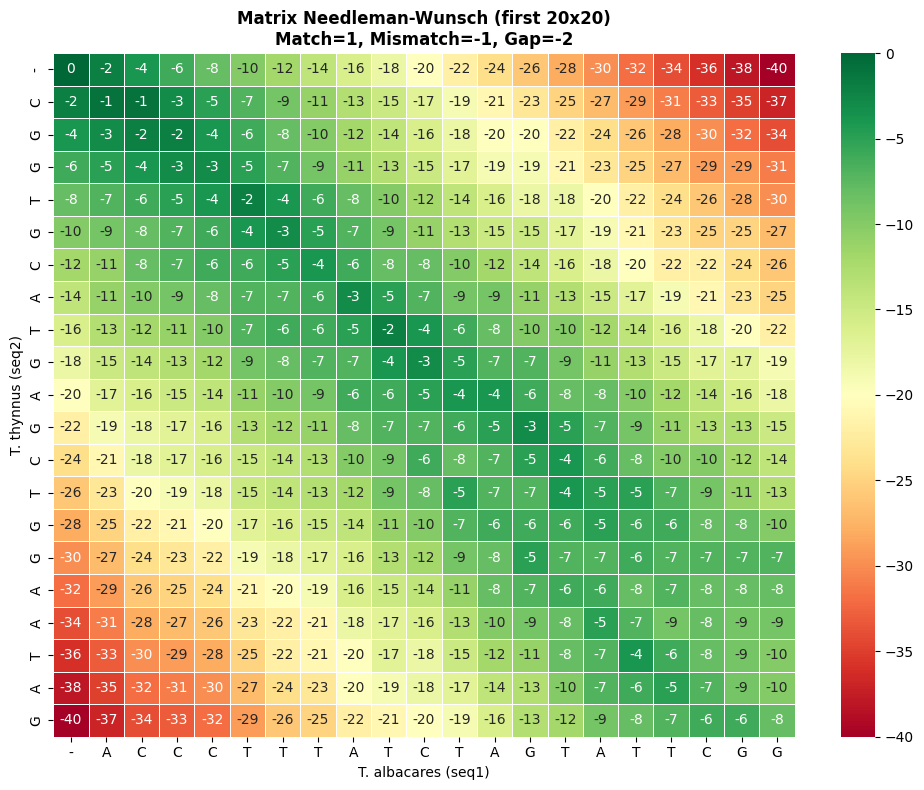

In [ ]:
vis_size = min(20, len(seq1), len(seq2))
matrix_size = matriks[:vis_size+1, :vis_size+1]

plt.figure(figsize=(10, 8))
sns.heatmap(
    matrix_size,
    annot=True,
    fmt="d",
    cmap="RdYlGn",
    linewidths=0.5,
    xticklabels=["-"] + list(seq1[:vis_size]),
    yticklabels=["-"] + list(seq2[:vis_size])
)
plt.title(f"Matrix Needleman-Wunsch (first 20x20)\nMatch={MATCH}, Mismatch={MISMATCH}, Gap={GAP}",
          fontweight='bold')
plt.xlabel("T. albacares (seq1)")
plt.ylabel("T. thynnus (seq2)")
plt.tight_layout()
plt.show()

**RESULTS VISUALIZATION GRAPH**

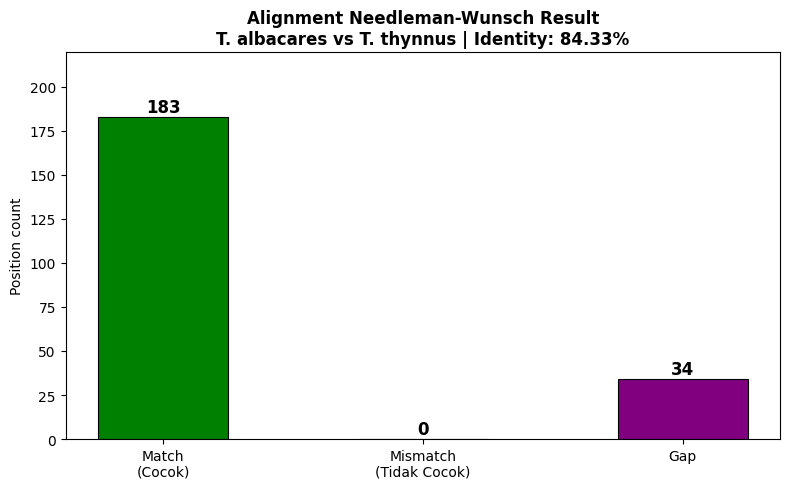

In [ ]:
plt.figure(figsize=(8, 5))
category = ['Match\n', 'Mismatch\n', 'Gap']
match_count = cocok
mismatch_count = sum(1 for a, b in zip(aligned1, aligned2)
                     if a != b and a != "-" and b != "-")
gap_count_vis = jumlah_gap
bar_score = [match_count, mismatch_count, gap_count_vis]
bar_color = ['green', 'red', 'purple']

bars = plt.bar(kategori, bar_score, color=bar_color, edgecolor='black', linewidth=0.8, width=0.5)
for bar, val in zip(bars, bar_score):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(val), ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title(f"Alignment Needleman-Wunsch Result\nT. albacares vs T. thynnus | Identity: {persen_identitas:.2f}%",
          fontweight='bold')
plt.ylabel("Position count")
plt.ylim(0, max(bar_score) * 1.2)
plt.tight_layout()
plt.show()